<a href="https://colab.research.google.com/github/chaietrader/Backenddata/blob/main/pair_trading.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -q yfinance statsmodels

In [ ]:
# ============================================================
# PAIRS TRADING ANALYSIS
# Bank of Baroda vs Union Bank of India
# ============================================================

# Install first if needed:
# pip install yfinance pandas numpy statsmodels scipy matplotlib

import numpy as np
import pandas as pd
import yfinance as yf
import statsmodels.api as sm

from statsmodels.tsa.stattools import adfuller
from datetime import datetime


# ------------------------------------------------------------
# 1. STOCK SELECTION
# ------------------------------------------------------------

BOB = "BANKBARODA.NS"
UNION = "UNIONBANK.NS"

stock_names = {
    BOB: "Bank of Baroda",
    UNION: "Union Bank of India"
}



In [ ]:
# ------------------------------------------------------------
# 2. DOWNLOAD 5 YEARS OF DATA
# ------------------------------------------------------------

end_date = datetime.today()
start_date = end_date - pd.DateOffset(years=5)

print("Downloading 5 years of stock data...")

raw = yf.download(
    [BOB, UNION],
    start=start_date,
    end=end_date,
    auto_adjust=True,      # Adjusts for stock splits/dividends
    progress=False
)

# Extract adjusted Close prices
close = raw["Close"].copy()

close = close.rename(
    columns={
        BOB: "BoB",
        UNION: "UnionBank"
    }
)


In [ ]:

# ------------------------------------------------------------
# 3. CLEAN DATA
# ------------------------------------------------------------

# Remove rows where either stock does not have a price
data = close.dropna()

# Remove duplicate dates
data = data[~data.index.duplicated(keep="first")]

# Sort by date
data = data.sort_index()

print("\nData period:")
print("From:", data.index.min().date())
print("To  :", data.index.max().date())

print("\nNumber of observations:", len(data))

print("\nLatest prices:")
print(data.tail())




Data period:
From: 2021-08-30
To  : 2026-08-28

Number of observations: 1240

Latest prices:
Ticker             BoB   UnionBank
Date                              
2026-08-24  241.500000  183.600006
2026-08-25  241.000000  186.979996
2026-08-26  242.500000  187.520004
2026-08-27  241.000000  184.500000
2026-08-28  241.899994  186.000000


In [ ]:

# ------------------------------------------------------------
# 4. CORRELATION OF CLOSE PRICES
# ------------------------------------------------------------

correlation = data["BoB"].corr(data["UnionBank"])

print("\n" + "=" * 60)
print("CORRELATION")
print("=" * 60)

print(f"Correlation = {correlation:.4f}")
print(f"Correlation % = {correlation * 100:.2f}%")

if correlation >= 0.75:
    print("PASS: Correlation is >= 75%")
else:
    print("FAIL: Correlation is below 75%")




CORRELATION
Correlation = 0.9589
Correlation % = 95.89%
PASS: Correlation is >= 75%


In [ ]:

# ------------------------------------------------------------
# FUNCTION TO RUN REGRESSION
# ------------------------------------------------------------

def run_regression(y, x, y_name, x_name):

    # Add intercept
    X = sm.add_constant(x)

    model = sm.OLS(y, X).fit()

    intercept = model.params["const"]
    slope = model.params[x.name]

    # Regression residuals
    residuals = model.resid

    # Standard deviation of residuals
    residual_std = residuals.std(ddof=1)
    print("X", x_name, "Y", y_name)
    print(residuals.tail(50))
    # Standard Error of Intercept
    intercept_se = model.bse["const"]

    return {
        "model": model,
        "Y": y_name,
        "X": x_name,
        "intercept": intercept,
        "slope": slope,
        "intercept_se": intercept_se,
        "residual_std": residual_std,
        "residuals": residuals
    }


# ------------------------------------------------------------
# 5A. REGRESSION 1
# Y = BoB
# X = Union Bank
# ------------------------------------------------------------

reg1 = run_regression(
    y=data["BoB"],
    x=data["UnionBank"],
    y_name="BoB",
    x_name="UnionBank"
)

print("\n" + "=" * 60)
print("REGRESSION 1")
print("Y = BoB")
print("X = Union Bank")
print("=" * 60)

print(f"Intercept                  : {reg1['intercept']:.6f}")
print(f"Slope / Hedge Ratio        : {reg1['slope']:.6f}")
print(f"Standard Error Intercept   : {reg1['intercept_se']:.6f}")
print(f"Std Dev of Residuals       : {reg1['residual_std']:.6f}")


# ------------------------------------------------------------
# 5B. REGRESSION 2
# Y = Union Bank
# X = BoB
# ------------------------------------------------------------

reg2 = run_regression(
    y=data["UnionBank"],
    x=data["BoB"],
    y_name="UnionBank",
    x_name="BoB"
)

print("\n" + "=" * 60)
print("REGRESSION 2")
print("Y = Union Bank")
print("X = BoB")
print("=" * 60)

print(f"Intercept                  : {reg2['intercept']:.6f}")
print(f"Slope / Hedge Ratio        : {reg2['slope']:.6f}")
print(f"Standard Error Intercept   : {reg2['intercept_se']:.6f}")
print(f"Std Dev of Residuals       : {reg2['residual_std']:.6f}")



X UnionBank Y BoB
Date
2026-06-22    -1.627654
2026-06-23    -7.914535
2026-06-24    -5.435001
2026-06-25    -6.027948
2026-06-26    -6.027948
2026-06-29   -12.181632
2026-06-30    -9.794011
2026-07-01   -13.750442
2026-07-02   -24.456801
2026-07-03   -24.072167
2026-07-06   -23.613933
2026-07-07   -25.713924
2026-07-08   -24.099931
2026-07-09   -23.816907
2026-07-10   -27.235450
2026-07-13   -35.458078
2026-07-14   -39.885331
2026-07-15   -40.639379
2026-07-16   -35.625313
2026-07-17   -36.707627
2026-07-20   -38.722564
2026-07-21   -46.115113
2026-07-22   -40.694918
2026-07-23   -40.276776
2026-07-24   -39.806288
2026-07-27   -41.730806
2026-07-28   -44.011207
2026-07-29   -43.687764
2026-07-30   -44.471544
2026-07-31   -44.653350
2026-08-03   -43.722129
2026-08-04   -45.972129
2026-08-05   -47.797418
2026-08-06   -51.424893
2026-08-07   -53.207026
2026-08-10   -52.782452
2026-08-11   -56.224896
2026-08-12   -57.488121
2026-08-13   -59.814429
2026-08-14   -60.780132
2026-08-17   -64.

In [ ]:

# ------------------------------------------------------------
# 5C. SELECT REGRESSION WITH LOWER RESIDUAL STANDARD DEVIATION
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("REGRESSION COMPARISON")
print("=" * 60)

comparison = pd.DataFrame({
    "Regression": [
        "Y=BoB, X=UnionBank",
        "Y=UnionBank, X=BoB"
    ],
    "Intercept_SE": [
        reg1["intercept_se"],
        reg2["intercept_se"]
    ],
    "Residual_STD": [
        reg1["residual_std"],
        reg2["residual_std"]
    ]
})

print(comparison.to_string(index=False))
reg1ratio = reg1["intercept_se"]/reg1["residual_std"]
reg2ratio = reg2["intercept_se"]/reg2["residual_std"]

# Choose based on LOWER STANDARD DEVIATION OF RESIDUAL
if reg1ratio < reg2ratio:
    selected = reg1
else:
    selected = reg2


print("\nSELECTED REGRESSION")
print("-------------------")
print(f"Y = {selected['Y']}")
print(f"X = {selected['X']}")
print(f"Residual Std Dev = {selected['residual_std']:.6f}")
print()




REGRESSION COMPARISON
        Regression  Intercept_SE  Residual_STD
Y=BoB, X=UnionBank      1.242675     18.760462
Y=UnionBank, X=BoB      1.154580     13.351344

SELECTED REGRESSION
-------------------
Y = BoB
X = UnionBank
Residual Std Dev = 18.760462



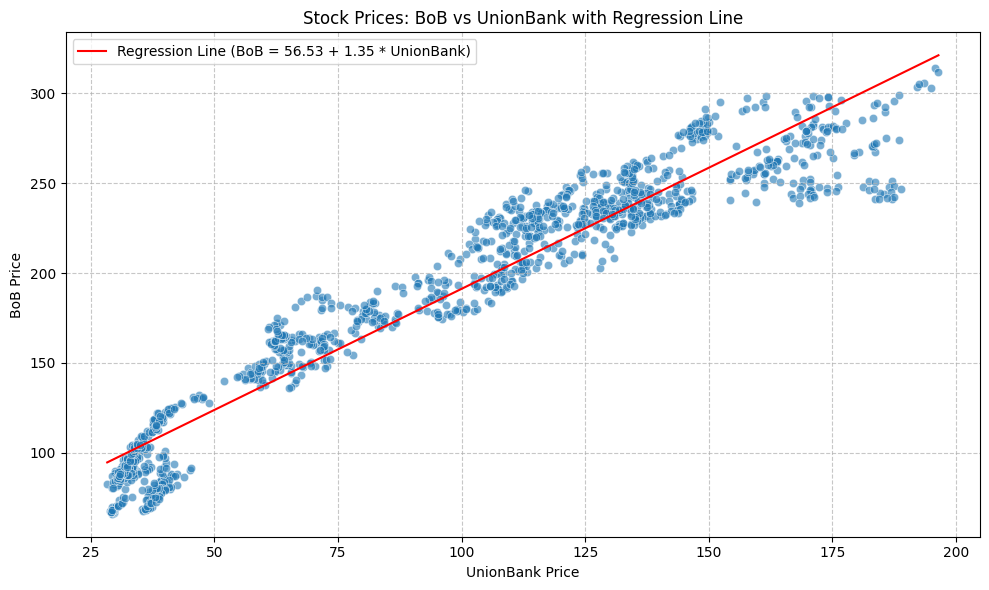

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get the Y and X data from the selected regression
y_data = data[selected['Y']]
x_data = data[selected['X']]

# Create the scatter plot
fig = plt.figure(figsize=(10, 6))
sns.scatterplot(x=x_data, y=y_data, alpha=0.6)

# Add the regression line
# y_pred = intercept + slope * x_data
regression_line_y = selected['intercept'] + selected['slope'] * x_data
sns.lineplot(x=x_data, y=regression_line_y, color='red', label=f'Regression Line ({selected["Y"]} = {selected["intercept"]:.2f} + {selected["slope"]:.2f} * {selected["X"]})')

plt.title(f'Stock Prices: {selected["Y"]} vs {selected["X"]} with Regression Line')
plt.xlabel(f'{selected["X"]} Price')
plt.ylabel(f'{selected["Y"]} Price')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:

# ------------------------------------------------------------
# 6. ADF TEST ON SELECTED RESIDUALS
# ------------------------------------------------------------

residuals = selected["residuals"]

adf_result = adfuller(
    residuals,
    autolag="AIC"
)

adf_stat = adf_result[0]
p_value = adf_result[1]

print("\n" + "=" * 60)
print("AUGMENTED DICKEY-FULLER TEST")
print("=" * 60)

print(f"ADF Statistic : {adf_stat:.6f}")
print(f"P-value       : {p_value:.6f}")

print("\nCritical Values:")

for key, value in adf_result[4].items():
    print(f"{key}: {value:.6f}")


# Pair confirmation
if p_value <= 0.05:
    pair_confirmed = True

    print("\nPASS")
    print("Residual series is statistically stationary.")
    print("Pair is CONFIRMED.")

else:
    pair_confirmed = False

    print("\nFAIL")
    print("Cannot reject non-stationarity.")
    print("Pair is NOT confirmed.")




AUGMENTED DICKEY-FULLER TEST
ADF Statistic : -1.790512
P-value       : 0.385182

Critical Values:
1%: -3.435643
5%: -2.863877
10%: -2.568014

FAIL
Cannot reject non-stationarity.
Pair is NOT confirmed.


In [ ]:

# ------------------------------------------------------------
# 7. TODAY / LATEST AVAILABLE STOCK VALUES
# ------------------------------------------------------------

latest = data.iloc[-1]

bob_today = latest["BoB"]
union_today = latest["UnionBank"]

latest_date = data.index[-1]

print("\n" + "=" * 60)
print("LATEST STOCK VALUES")
print("=" * 60)

print(f"Date             : {latest_date.date()}")
print(f"Bank of Baroda   : {bob_today:.2f}")
print(f"Union Bank       : {union_today:.2f}")




LATEST STOCK VALUES
Date             : 2026-08-27
Bank of Baroda   : 241.00
Union Bank       : 184.50


In [ ]:

# ------------------------------------------------------------
# 8. CALCULATE TODAY'S RESIDUAL
# ------------------------------------------------------------

intercept = selected["intercept"]
slope = selected["slope"]

if selected["Y"] == "BoB":

    # BoB = intercept + beta * UnionBank
    predicted_y = intercept + slope * union_today

    today_residual = bob_today - predicted_y

else:

    # UnionBank = intercept + beta * BoB
    predicted_y = intercept + slope * bob_today

    today_residual = union_today - predicted_y



In [ ]:

# ------------------------------------------------------------
# 9. TODAY RESIDUAL / STANDARD DEVIATION OF RESIDUAL
# ------------------------------------------------------------

residual_std = selected["residual_std"]

today_zscore = today_residual / residual_std


print("\n" + "=" * 60)
print("TODAY RESIDUAL ANALYSIS")
print("=" * 60)

print(f"Regression:")
print(
    f"{selected['Y']} = "
    f"{intercept:.6f} + "
    f"{slope:.6f} × {selected['X']}"
)

print(f"\nPredicted Y                : {predicted_y:.6f}")
print(f"Actual Y                   : "
      f"{bob_today if selected['Y']=='BoB' else union_today:.6f}")

print(f"Today's Residual           : {today_residual:.6f}")
print(f"Residual Standard Deviation: {residual_std:.6f}")

print(
    f"\nToday's Residual / "
    f"Std Dev of Residual = {today_zscore:.4f}"
)




TODAY RESIDUAL ANALYSIS
Regression:
UnionBank = -30.547193 + 0.681930 × BoB

Predicted Y                : 133.797865
Actual Y                   : 184.500000
Today's Residual           : 50.702135
Residual Standard Deviation: 13.276123

Today's Residual / Std Dev of Residual = 3.8190


In [ ]:

# ------------------------------------------------------------
# 10. INTERPRET Z-SCORE
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("Z-SCORE INTERPRETATION")
print("=" * 60)

if abs(today_zscore) < 1:
    print("Residual is within 1 standard deviation.")

elif abs(today_zscore) < 2:
    print("Residual is between 1 and 2 standard deviations.")

elif abs(today_zscore) < 3:
    print("Residual is between 2 and 3 standard deviations.")

else:
    print("Residual is more than 3 standard deviations.")




Z-SCORE INTERPRETATION
Residual is more than 3 standard deviations.


In [ ]:

# ------------------------------------------------------------
# 11. FINAL SUMMARY
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("FINAL SUMMARY")
print("=" * 60)

print(f"""
Correlation                : {correlation:.4f}
Correlation >= 75%         : {correlation >= 0.75}

Selected Y                 : {selected['Y']}
Selected X                 : {selected['X']}

Regression Intercept       : {intercept:.6f}
Regression Slope           : {slope:.6f}

Intercept Standard Error   : {selected['intercept_se']:.6f}
Residual Standard Deviation: {residual_std:.6f}

ADF P-value                : {p_value:.6f}
Stationary at 5%           : {p_value <= 0.05}
Pair Confirmed             : {pair_confirmed}

Latest Date                : {latest_date.date()}
BoB Price                  : {bob_today:.2f}
Union Bank Price           : {union_today:.2f}

Today's Residual           : {today_residual:.6f}
Today's Residual Z-score   : {today_zscore:.4f}
""")


FINAL SUMMARY

Correlation                : 0.9593
Correlation >= 75%         : True

Selected Y                 : UnionBank
Selected X                 : BoB

Regression Intercept       : -30.547193
Regression Slope           : 0.681930

Intercept Standard Error   : 1.148154
Residual Standard Deviation: 13.276123

ADF P-value                : 0.663560
Stationary at 5%           : False
Pair Confirmed             : False

Latest Date                : 2026-08-27
BoB Price                  : 241.00
Union Bank Price           : 184.50

Today's Residual           : 50.702135
Today's Residual Z-score   : 3.8190

